# S7-2 CDSプライシングとハザードカーブのブートストラップ

## 学習目標

- CDS を「プレミアムレッグとプロテクションレッグの交換」として捉え、両レッグの
  現在価値を割引係数と生存確率から自力で組み立てられる
- パースプレッド（par spread）が $\dfrac{\text{プロテクションレッグ PV}}{\text{リスキーアニュイティ}}$
  に落ちる式を導き、経過保険料（accrual on default）まで含めて評価できる
- CDS タームストラクチャからハザードカーブを逐次に剥ぎ取るブートストラップを実装し、
  `bondlab.credit.cds_par_spread` / `bootstrap_hazard` と一致することを確認できる
- 自作エンジンを QuantLib の `CreditDefaultSwap` + `MidPointCdsEngine` と突合できる
- 固定クーポン＋アップフロント方式（ISDA 標準モデル）の意味を説明し、スプレッド拡大時の
  MTM 変化とクレジット DV01（CS01）を数値微分で計算できる

## 実務での位置づけ（ファンドはどう稼ぐか）

CDS はクレジットデスクとクレジットヘッジファンドの主力商品です。docs の収益源に当てはめると、稼ぎ方は三つに整理できます。第一に**キャリー**：プロテクションを売る（信用リスクを引き受ける）と、生存している間はパースプレッド分の保険料が入り続けます。現物社債を持たずにレバレッジをかけて信用エクスポージャーを取れるので、資金効率の良いキャリー手段です。第二に**方向性**：信用悪化を見込めばプロテクションを買い、改善を見込めば売る。第三に**相対価値**：同一発行体の CDS スプレッドと現物社債スプレッドの差（CDS-ボンド・ベーシス）や、3年と5年と10年のクレジットカーブの傾き（カーブ・スティープナー／フラットナー）の歪みに賭けます。いずれもブートストラップしたハザードカーブが「どの年限が割高・割安か」を判定する物差しになります。

この notebook で計算する CS01（クレジット DV01、スプレッドが1bp 動いたときの MTM 変化）は、クレジットデスクのリスク管理の基本単位です。ポジションを CS01 で束ねれば、発行体別・年限別の信用エクスポージャーを合算でき、ヘッジ比率もこの感応度で決めます。たとえばベーシス取引では、現物社債のスプレッド感応度と CDS の CS01 を揃えて、金利リスクだけでなく信用リスクも中立化したうえでベーシスの収束だけを取りにいきます。ISDA 標準の固定クーポン＋アップフロント方式を理解しておくと、スプレッド拡大時にアップフロントがどう動き、MTM がどう出るかを日次で追えます。

セルサイドのクレジット・マーケットメイカーは、CDS のビッド・オファーを両面提示して顧客フローをさばき、在庫として抱えた信用リスクをハザードカーブ上で評価・ヘッジします。ここでの par spread の計算とブートストラップは、その値付けとリスク集計そのものです。さらに XVA デスクは、CDS 市場から剥ぎ取ったハザードカーブをカウンターパーティの生存確率として使い、CVA を価格化・ヘッジします（S7-5）。CDS の流動性が高い発行体ほど、CVA の信用デルタを実際の CDS でヘッジしやすくなります。


## 理論

### CDS の仕組み：プレミアムレッグとプロテクションレッグ

クレジット・デフォルト・スワップ（CDS, credit default swap）は、ある参照企業の
デフォルトに対する保険です。プロテクションの買い手は保険料を定期的に払い、
参照企業がデフォルトしたら損失を補填してもらいます。契約は二つのキャッシュフローの
交換として表せます。

- **プレミアムレッグ（premium leg）**：買い手が売り手へ、想定元本 $N$ に対して
  四半期ごとにスプレッド $s$ の保険料 $N \cdot s \cdot \tau_i$ を払う。ただし参照企業が
  生存している間だけ払い、デフォルトすれば以降の保険料は止まる。
- **プロテクションレッグ（protection leg）**：参照企業がデフォルトした瞬間に、
  売り手が買い手へ $N \cdot (1 - R)$ を払う。$R$ は回収率（recovery rate）で、
  デフォルト後に額面のうち回収できる割合です。

生存確率を $S(t)$、割引係数を $DF(t)$ とします。$S(t) = \exp(-\int_0^t \lambda(u)\,du)$
で、$\lambda$ はハザードレート（hazard rate, 瞬間デフォルト強度）です。区間 $[t, t+dt]$ で
デフォルトする確率は $-dS(t) = S(t)\lambda(t)\,dt$ と書けます。

### 各レッグの現在価値

プレミアムレッグは、保険料が「生存している時点でのみ」発生することに注意して割り引きます。
支払時点を $t_1 < t_2 < \dots < t_n$、各期間長を $\tau_i$ とすると、生存時保険料の PV は

$$
\text{Premium}_{\text{生存}} = N \, s \sum_{i=1}^{n} \tau_i \, DF(t_i)\, S(t_i).
$$

プロテクションレッグは、デフォルトが起きた瞬間に支払うので、デフォルト時刻について積分します。

$$
\text{Protection} = N\,(1 - R) \int_0^T DF(t)\,\bigl(-dS(t)\bigr)
 = N\,(1 - R)\int_0^T DF(t)\,S(t)\,\lambda(t)\,dt.
$$

### 経過保険料（accrual on default）

参照企業が二つの支払日の**間**でデフォルトすると、直前の支払日からデフォルト時点までの
保険料が未払いのまま残ります。実際の CDS 契約では、この経過分（accrual on default）を
買い手がデフォルト時に精算します。区間内で一様にデフォルトすると仮定すると、平均して
期間の半分だけ経過した時点で払うと近似でき、区間ごとに

$$
\text{Premium}_{\text{経過}} = N\, s \sum_{i=1}^{n} \tfrac{1}{2}\,\tau_i\, DF(m_i)\,\bigl(S(t_{i-1}) - S(t_i)\bigr),
\qquad m_i = \tfrac{t_{i-1}+t_i}{2}
$$

を足します。$S(t_{i-1}) - S(t_i)$ が区間 $[t_{i-1}, t_i]$ 内でデフォルトする確率です。
この項を入れておくと、後述の QuantLib の CDS フェアスプレッドとほぼ一致します（本 notebook の
`bondlab` 実装はこれを組み込んであり、QuantLib と約 0.02bp で一致します）。

### パースプレッドの式

スプレッド $s$ に依存しない部分を切り出すと便利です。生存保険料と経過保険料の和は
$s$ の一次式なので、スプレッド1あたりのプレミアムレッグ PV を**リスキーアニュイティ**
（risky annuity）$A$ と呼びます。

$$
A = \sum_{i=1}^{n} \tau_i\, DF(t_i)\, S(t_i)
  + \sum_{i=1}^{n} \tfrac{1}{2}\,\tau_i\, DF(m_i)\,\bigl(S(t_{i-1}) - S(t_i)\bigr).
$$

契約時に両レッグの価値が釣り合う（正味価値ゼロ）スプレッドが**パースプレッド**
（par spread）$s^\ast$ です。$N$ で割ると

$$
N\,s^\ast A = \text{Protection}/N \cdot N
\;\Longrightarrow\;
s^\ast = \frac{(1-R)\int_0^T DF(t)\,(-dS(t))}{A}
= \frac{\text{プロテクションレッグ PV}}{\text{リスキーアニュイティ}}.
$$

分子・分子ともに想定元本1あたりで測れば $N$ は消えます。以降は $N=1$ で計算し、
金額が必要なときに $N$ を掛けます。

### 固定クーポン＋アップフロント方式へ移行した経緯

昔の CDS は、契約ごとにスプレッドを par spread に設定し、アップフロント授受をゼロにする
方式でした。しかしこの方式では、同じ参照企業でも取引ごとにクーポンがバラバラになり、
ネッティング（相殺）や中央清算がやりにくいという難点がありました。同一銘柄の反対売買でも
クーポンが違えば残高が完全には打ち消せません。

2009年のいわゆる「CDS ビッグバン／スモールバン」で、ISDA 標準モデル（ISDA standard model）に
基づく**固定クーポン＋アップフロント**（fixed coupon + upfront）方式へ移行しました。
クーポンを投資適格なら 100bp、ハイイールドなら 500bp のように標準化し、市場スプレッドとの
差は契約時の一括授受（アップフロント, upfront）で調整します。標準化されたクーポンの CDS は
銘柄ごとにフルに相殺でき、中央清算機関での扱いも揃います。

想定元本1あたりのアップフロント（買い手が払う額、ポイント表示）は、固定クーポンを
$c$ として

$$
\text{Upfront} = \text{Protection} - c\,A = (s^\ast - c)\,A
$$

と書けます。市場スプレッド $s^\ast$ がクーポン $c$ より高ければ買い手はアップフロントを払い、
低ければ受け取ります。

### CS01（クレジット DV01）の定義

既存契約の時価（MTM, mark-to-market）は、契約クーポン $c$ を固定したまま、その時点の
ハザードカーブで両レッグを再評価した差です。プロテクション買い手にとって

$$
\text{MTM}_{\text{買い}} = N\,\bigl(\text{Protection} - c\,A\bigr).
$$

**CS01**（credit spread 01、クレジット DV01）は、CDS スプレッドが一律 1bp 動いたときの
MTM 変化額です。

$$
\text{CS01} = \frac{\partial\,\text{MTM}}{\partial s}\Big/10^4
\;\approx\; \text{MTM}(s + 1\text{bp}) - \text{MTM}(s).
$$

金利の DV01 に対応するクレジットの感応度で、スプレッド拡大に対するポジションの
損益を測る基本量です。数値微分で求めるのが実務的で確実です。

**数値例**：連続複利 2% 割引・一定ハザード $\lambda=0.02$・$R=0.4$ の5年 CDS（四半期払い）では、リスキーアニュイティ $A\approx 4.520$、プロテクションレッグ PV $\approx 0.0544$ なので、パースプレッドは $s^\ast=0.0544/4.520\approx 0.01203$（120.3bp）となり、近似 $\lambda(1-R)=120$bp とほぼ一致します。

**数値例**：固定クーポン $c=100$bp のとき、この5年 CDS のアップフロントは $(s^\ast-c)\,A=(0.01203-0.01)\times 4.520\approx 0.0092$（約 0.92 ポイント＝想定元本の 0.92%）で、$s^\ast>c$ なので買い手が支払います。

**数値例**：CS01 はほぼ $A\times 1\text{bp}$ に等しいので、想定元本 1,000万円なら $4.520\times 10^{-4}\times 10^{7}\approx 4{,}520$ 円/bp の MTM 変化になります。


## スクラッチ実装

### 使用する自作関数

`bondlab` に頼らず、両レッグの評価とハザードブートストラップを numpy だけで組みます。
区分定数ハザードから生存確率を作り、上の理論式をそのまま数値化します。積分グリッドと
経過保険料の近似は `bondlab.credit.cds_legs` と同じ取り決め（プロテクション積分は
$200 \times$ 満期分割、経過は中点近似）に揃え、最後に一致を確認します。

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `survival(times, hazards, t)` | ノード年数, 区間ハザード, 評価時点 | 生存確率 $S(t)$ | 区分定数 $\lambda$ から $S$ を計算 |
| `cds_legs_scratch(times, hazards, disc, T, R, freq)` | ハザード, 割引カーブ, 満期, 回収率, 頻度 | $(A,\ \text{Protection})$ | 両レッグを評価 |
| `par_spread_scratch(...)` | 同上 | パースプレッド | プロテクション PV / リスキーアニュイティ |
| `bootstrap_hazard_scratch(disc, tenors, spreads, R, freq)` | 割引カーブ, テナー, スプレッド列, 回収率, 頻度 | $(\text{times}, \text{hazards})$ | タームストラクチャから $\lambda$ を剥ぎ取る |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from scipy.optimize import brentq

import bondlab
from bondlab.curve import DiscountCurve
from bondlab.credit import (
    HazardCurve,
    cds_legs,
    cds_par_spread,
    bootstrap_hazard,
)

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


def survival(times, hazards, t):
    """区分定数ハザード $\\lambda$ から生存確率 $S(t)=\\exp(-\\int_0^t\\lambda)$ を返す。

    times は各区間の右端（年、昇順）、hazards は対応区間のハザード。最終ノードより
    先は最後のハザードで外挿する。スカラー・配列の両方に対応する。
    """
    times = np.asarray(times, dtype=float)
    hazards = np.asarray(hazards, dtype=float)
    edges = np.concatenate([[0.0], times])
    cumh = np.concatenate([[0.0], np.cumsum(np.diff(edges) * hazards)])

    def cum_one(tt):
        if tt <= 0:
            return 0.0
        i = int(np.searchsorted(times, tt))
        if i >= len(times):  # 最終ノードより先は最後の λ で延長
            return cumh[-1] + (tt - times[-1]) * hazards[-1]
        return cumh[i] + (tt - edges[i]) * hazards[i]

    t = np.asarray(t, dtype=float)
    if t.ndim == 0:
        return float(np.exp(-cum_one(float(t))))
    return np.exp(-np.array([cum_one(float(x)) for x in t]))


def cds_legs_scratch(times, hazards, disc, maturity, recovery=0.4, freq=4):
    """リスキーアニュイティ $A$（スプレッド1あたりのプレミアムレッグ PV）と
    プロテクションレッグ PV を返す。経過保険料（accrual on default）を含める。
    """
    tau = 1.0 / freq
    pay_times = np.arange(1, int(round(maturity * freq)) + 1) / freq
    surv = survival(times, hazards, pay_times)

    # 生存時の保険料（スプレッド1あたり）
    annuity = float(np.sum(tau * disc.discount(pay_times) * surv))

    # 経過保険料：各区間でデフォルトすると平均で τ/2 の経過分を払う
    prev = np.concatenate([[0.0], pay_times[:-1]])
    s_prev = survival(times, hazards, prev)
    dS_period = s_prev - surv                      # 区間内デフォルト確率
    mid = 0.5 * (prev + pay_times)
    annuity += float(np.sum(0.5 * tau * disc.discount(mid) * dS_period))

    # プロテクションレッグ：細かいグリッドで ∫ DF(t)(-dS)
    n_int = int(round(maturity * 200))
    grid = np.linspace(0.0, maturity, n_int + 1)
    S = survival(times, hazards, grid)
    DF = disc.discount(0.5 * (grid[1:] + grid[:-1]))
    dS = -(S[1:] - S[:-1])
    protection = float((1 - recovery) * np.sum(DF * dS))
    return annuity, protection


def par_spread_scratch(times, hazards, disc, maturity, recovery=0.4, freq=4):
    """パースプレッド = プロテクションレッグ PV / リスキーアニュイティ。"""
    ann, prot = cds_legs_scratch(times, hazards, disc, maturity, recovery, freq)
    return prot / ann


def bootstrap_hazard_scratch(disc, tenors, spreads, recovery=0.4, freq=4):
    """CDS パースプレッド列から区分定数ハザードカーブを逐次に剥ぎ取る。

    テナーの短い順に、その区間のハザード λ を1つずつ求根で解く。既に確定した
    短いテナーのハザードは固定し、追加した1本だけを未知数にする。
    """
    tenors = np.asarray(tenors, dtype=float)
    spreads = np.asarray(spreads, dtype=float)
    hazards = []
    for i, (T, s) in enumerate(zip(tenors, spreads)):
        def obj(lam, i=i, T=T, s=s):
            h = np.array(hazards + [lam])
            return par_spread_scratch(tenors[: i + 1], h, disc, T, recovery, freq) - s
        lam = brentq(obj, 1e-8, 5.0, xtol=1e-12, maxiter=200)
        hazards.append(lam)
    return tenors, np.array(hazards)

bondlab version: 0.0.1


### 割引カーブとハザードの準備

割引は連続複利 2% のフラットカーブとします（QuantLib の `FlatForward(0.02)` に対応）。
まず単一テナー・一定ハザード $\lambda=2\%$ で、自作エンジンと `bondlab` のパースプレッドが
一致することを確認します。

In [2]:
# 連続複利 2% フラット割引カーブ（十分細かいノードで表現）
tg = np.linspace(0.25, 30.0, 120)
disc = DiscountCurve(tg, np.exp(-0.02 * tg))

lam = 0.02
maturity = 5.0

sp_scratch = par_spread_scratch([maturity], [lam], disc, maturity, recovery=0.4, freq=4)
haz_bl = HazardCurve([maturity], [lam])
sp_bl = cds_par_spread(haz_bl, disc, maturity, recovery=0.4, freq=4)

print(f"自作 par spread   = {sp_scratch * 1e4:.4f} bp")
print(f"bondlab par spread = {sp_bl * 1e4:.4f} bp")
print(f"差               = {(sp_scratch - sp_bl) * 1e4:.2e} bp")

ann_s, prot_s = cds_legs_scratch([maturity], [lam], disc, maturity, 0.4, 4)
ann_b, prot_b = cds_legs(haz_bl, disc, maturity, 0.4, 4)
print(f"\nリスキーアニュイティ  自作={ann_s:.6f}  bondlab={ann_b:.6f}")
print(f"プロテクション PV     自作={prot_s:.6f}  bondlab={prot_b:.6f}")

assert abs(sp_scratch - sp_bl) < 1e-10
assert abs(ann_s - ann_b) < 1e-10 and abs(prot_s - prot_b) < 1e-10
print("\n自作エンジンと bondlab が一致しました")

自作 par spread   = 120.2997 bp
bondlab par spread = 120.2997 bp
差               = 0.00e+00 bp

リスキーアニュイティ  自作=4.520440  bondlab=4.520440
プロテクション PV     自作=0.054381  bondlab=0.054381

自作エンジンと bondlab が一致しました


### ハザードブートストラップの一致確認

複数テナーの CDS パースプレッド列から、区分定数ハザードを剥ぎ取ります。自作の
ブートストラップと `bondlab.credit.bootstrap_hazard` が同じハザードを返すこと、
そして剥ぎ取ったハザードで再計算したパースプレッドが入力に戻ることを確かめます。

In [3]:
tenors = np.array([1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
quotes = np.array([80, 100, 120, 150, 165, 180]) / 1e4  # bp → 小数

times_s, haz_s = bootstrap_hazard_scratch(disc, tenors, quotes, recovery=0.4, freq=4)
hc_bl = bootstrap_hazard(disc, tenors, quotes, recovery=0.4, freq=4)

print("テナー(年)  自作ハザード  bondlabハザード   再構築スプレッド(bp)")
for T, hs, hb in zip(tenors, haz_s, hc_bl.hazards):
    recon = par_spread_scratch(times_s, haz_s, disc, T, 0.4, 4) * 1e4
    print(f"{T:6.0f}     {hs:10.6f}   {hb:12.6f}     {recon:10.4f}")

assert np.allclose(haz_s, hc_bl.hazards, atol=1e-10)
recon_all = np.array([par_spread_scratch(times_s, haz_s, disc, T, 0.4, 4) for T in tenors])
assert np.allclose(recon_all, quotes, atol=1e-10)
print("\nブートストラップが bondlab と一致し、入力スプレッドを再現しました")

テナー(年)  自作ハザード  bondlabハザード   再構築スプレッド(bp)
     1       0.013300       0.013300        80.0000
     2       0.020074       0.020074       100.0000
     3       0.027026       0.027026       120.0000
     5       0.033358       0.033358       150.0000
     7       0.034902       0.034902       165.0000
    10       0.037570       0.037570       180.0000

ブートストラップが bondlab と一致し、入力スプレッドを再現しました


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


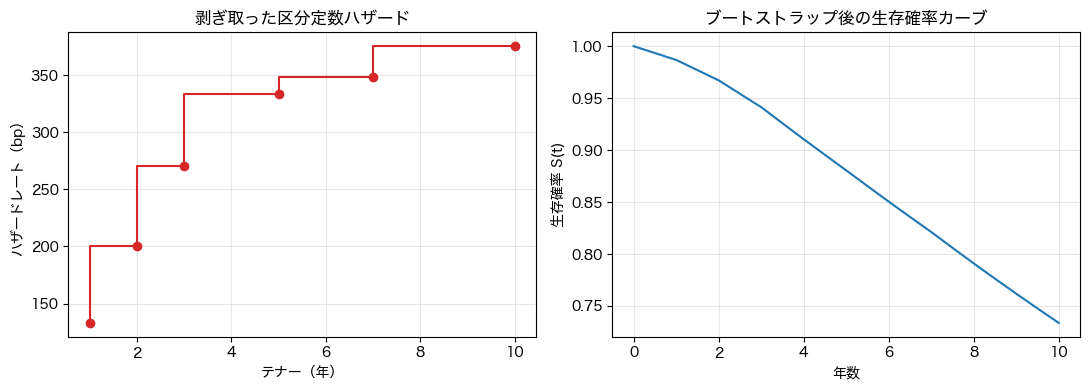

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.step(tenors, haz_s * 1e4, where="pre", color="#d62728", marker="o")
ax1.set_xlabel("テナー（年）")
ax1.set_ylabel("ハザードレート（bp）")
ax1.set_title("剥ぎ取った区分定数ハザード")
ax1.grid(alpha=0.3)

grid = np.linspace(0.0, 10.0, 200)
ax2.plot(grid, survival(times_s, haz_s, grid), color="#1f77b4")
ax2.set_xlabel("年数")
ax2.set_ylabel("生存確率 S(t)")
ax2.set_title("ブートストラップ後の生存確率カーブ")
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## QuantLib検証

QuantLib の `CreditDefaultSwap` を `MidPointCdsEngine` で評価し、フェアスプレッド
（par spread）を求めます。`MidPointCdsEngine` はデフォルト時刻を各区間の中点で近似する
エンジンで、経過保険料を含みます。自作・`bondlab` の実装が QuantLib と約 0.02bp で
一致することを確認します。

In [5]:
import QuantLib as ql

today = ql.Date(1, 1, 2026)
ql.Settings.instance().evaluationDate = today

disc_ql = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.02, ql.Actual365Fixed())
)


def ql_fair_spread(lam, maturity_years, recovery=0.4):
    """QuantLib の CDS フェアスプレッドを返す（一定ハザード λ）。"""
    end = today + ql.Period(maturity_years, ql.Years)
    haz = ql.HazardRateCurve([today, end], [lam, lam], ql.Actual365Fixed())
    haz.enableExtrapolation()
    sched = ql.MakeSchedule(today, end, ql.Period(ql.Quarterly))
    cds = ql.CreditDefaultSwap(
        ql.Protection.Buyer, 1e6, 0.01, sched, ql.Following, ql.Actual365Fixed()
    )
    cds.setPricingEngine(
        ql.MidPointCdsEngine(
            ql.DefaultProbabilityTermStructureHandle(haz), recovery, disc_ql
        )
    )
    return cds.fairSpread()


print(f"{'満期(年)':>8}  {'自作(bp)':>10}  {'bondlab(bp)':>12}  {'QuantLib(bp)':>13}  {'差(bp)':>8}")
for T in [1, 3, 5, 7, 10]:
    s_scr = par_spread_scratch([float(T)], [lam], disc, float(T), 0.4, 4) * 1e4
    s_bl = cds_par_spread(HazardCurve([float(T)], [lam]), disc, float(T), 0.4, 4) * 1e4
    s_ql = ql_fair_spread(lam, T) * 1e4
    print(f"{T:8d}  {s_scr:10.4f}  {s_bl:12.4f}  {s_ql:13.4f}  {s_scr - s_ql:8.4f}")

# 5年で 0.02bp 以内に収まることを明示的に確認する
diff_5y = abs(par_spread_scratch([5.0], [lam], disc, 5.0, 0.4, 4) - ql_fair_spread(lam, 5)) * 1e4
print(f"\n5年 CDS の自作 vs QuantLib 差 = {diff_5y:.4f} bp")
assert diff_5y < 0.02
print("QuantLib と 0.02bp 以内で一致しました")

   満期(年)      自作(bp)   bondlab(bp)   QuantLib(bp)     差(bp)


       1    120.2997      120.2997       120.3010   -0.0013
       3    120.2997      120.2997       120.3018   -0.0021
       5    120.2997      120.2997       120.3015   -0.0018
       7    120.2997      120.2997       120.3017   -0.0020
      10    120.2997      120.2997       120.3015   -0.0018

5年 CDS の自作 vs QuantLib 差 = 0.0018 bp
QuantLib と 0.02bp 以内で一致しました


## 実データ適用

### 合成 CDS タームストラクチャ（ISDA 標準モデル形式）

ある投資適格の参照企業について、ISDA 標準モデル形式のクォートを想定します。市場は
パースプレッドを気配で提示し、固定クーポン $c=100\text{bp}$（投資適格の標準）と回収率
$R=40\%$ を前提に、アップフロントへ換算します。まずタームストラクチャからハザードを
剥ぎ取り、各テナーのアップフロント（ポイント表示）を求めます。

In [6]:
recovery = 0.40
coupon = 0.01  # 固定クーポン 100bp（投資適格の標準）
notional = 10_000_000.0  # 想定元本 1,000万円

cds_tenors = np.array([1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
cds_quotes = np.array([60, 80, 95, 100, 115, 130]) / 1e4  # パースプレッド(bp)

times0, haz0 = bootstrap_hazard_scratch(disc, cds_tenors, cds_quotes, recovery, freq=4)

print(f"{'テナー':>6}  {'par(bp)':>8}  {'ハザード':>10}  {'アップフロント(pt)':>16}")
for T, s in zip(cds_tenors, cds_quotes):
    ann, prot = cds_legs_scratch(times0, haz0, disc, T, recovery, 4)
    upfront = prot - coupon * ann  # 想定元本1あたり
    print(f"{T:6.0f}  {s * 1e4:8.2f}  "
          f"{haz0[np.searchsorted(cds_tenors, T)]:10.6f}  {upfront * 100:16.4f}")

   テナー   par(bp)        ハザード       アップフロント(pt)
     1     60.00    0.009975           -0.3931
     2     80.00    0.016738           -0.3866
     3     95.00    0.021067           -0.1424
     5    100.00    0.017997            0.0000
     7    115.00    0.026310            0.9237
    10    130.00    0.028886            2.4807


### 5年 CDS のスプレッド拡大と MTM 変化

5年 CDS のプロテクションを par（100bp）で買った投資家を考えます。契約時は par で
買ったのでアップフロントはほぼゼロ、MTM もゼロです。その後クレジットが悪化し、
5年パースプレッドが 300bp まで拡大したときの MTM 変化を計算します。買い手にとって
スプレッド拡大は利益（安く買った保険が値上がりする）です。

In [7]:
def mtm_buyer(par_spread, coupon, maturity, notional, recovery=0.4, freq=4):
    """5年 CDS を par_spread と整合な一定ハザードで再評価したときの、
    固定クーポン coupon のプロテクション買い手の MTM（金額）を返す。
    """
    times_h, haz_h = bootstrap_hazard_scratch(
        disc, [maturity], [par_spread], recovery, freq
    )
    ann, prot = cds_legs_scratch(times_h, haz_h, disc, maturity, recovery, freq)
    return notional * (prot - coupon * ann), ann


mtm_100, ann_100 = mtm_buyer(0.0100, coupon, 5.0, notional, recovery)
mtm_300, ann_300 = mtm_buyer(0.0300, coupon, 5.0, notional, recovery)

print(f"契約時（par=100bp）  MTM = {mtm_100:>14,.2f} 円")
print(f"拡大後（par=300bp）  MTM = {mtm_300:>14,.2f} 円")
print(f"MTM 変化            ΔMTM = {mtm_300 - mtm_100:>14,.2f} 円")
print(f"\n近似 (s-c)·A·N      = {(0.0300 - coupon) * ann_300 * notional:>14,.2f} 円")

assert mtm_300 > mtm_100  # 買い手はスプレッド拡大で利益
assert abs(mtm_100) < 1.0  # par で買った契約は時価ほぼゼロ

契約時（par=100bp）  MTM =          -0.00 円
拡大後（par=300bp）  MTM =     841,905.61 円
MTM 変化            ΔMTM =     841,905.61 円

近似 (s-c)·A·N      =     841,905.61 円


### CS01（クレジット DV01）の実装

CS01 はスプレッドが 1bp 動いたときの MTM 変化額です。数値微分（1bp 上げて差を取る）で
求めます。スプレッド水準ごとに CS01 がどう変わるかも見ます。MTM はスプレッドに対して
ほぼ線形（リスキーアニュイティ倍）なので、CS01 はアニュイティにほぼ等しく、スプレッド
拡大に伴ってアニュイティが縮む分だけ緩やかに小さくなります。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


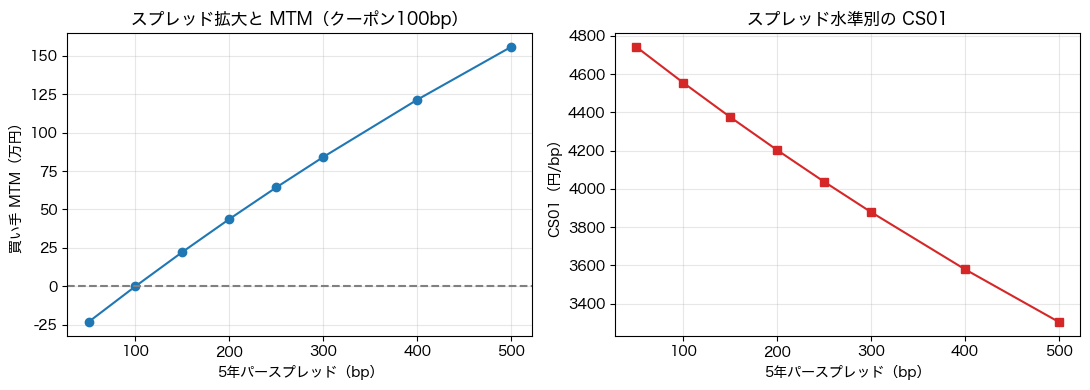

In [8]:
def cs01(par_spread, coupon, maturity, notional, recovery=0.4, freq=4, bump=1e-4):
    """CS01 = MTM(s + 1bp) - MTM(s)。プロテクション買い手・金額表示。"""
    m0, _ = mtm_buyer(par_spread, coupon, maturity, notional, recovery, freq)
    m1, _ = mtm_buyer(par_spread + bump, coupon, maturity, notional, recovery, freq)
    return m1 - m0


levels = np.array([50, 100, 150, 200, 250, 300, 400, 500]) / 1e4
cs01_vals = np.array([cs01(s, coupon, 5.0, notional, recovery) for s in levels])
mtm_vals = np.array([mtm_buyer(s, coupon, 5.0, notional, recovery)[0] for s in levels])

print(f"{'par(bp)':>8}  {'MTM(円)':>16}  {'CS01(円/bp)':>14}")
for s, m, c in zip(levels, mtm_vals, cs01_vals):
    print(f"{s * 1e4:8.0f}  {m:16,.2f}  {c:14,.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(levels * 1e4, mtm_vals / 1e4, "o-", color="#1f77b4")
ax1.axhline(0.0, ls="--", color="gray")
ax1.set_xlabel("5年パースプレッド（bp）")
ax1.set_ylabel("買い手 MTM（万円）")
ax1.set_title("スプレッド拡大と MTM（クーポン100bp）")
ax1.grid(alpha=0.3)

ax2.plot(levels * 1e4, cs01_vals, "s-", color="#d62728")
ax2.set_xlabel("5年パースプレッド（bp）")
ax2.set_ylabel("CS01（円/bp）")
ax2.set_title("スプレッド水準別の CS01")
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

MTM はスプレッドに対してほぼ直線で、その傾きが CS01 です。スプレッドが高い（クレジットが
悪い）ほど生存確率が下がってリスキーアニュイティが縮むため、CS01 は緩やかに逓減します。
デフォルトが近いポジションほど、1bp あたりの感応度がわずかに鈍る、という直感どおりです。

## 演習

1. **タームストラクチャからのハザード剥ぎ取りと再構築**
   次の 6 テナーの CDS パースプレッド（bp）を入力とする。
   `1Y:70, 2Y:90, 3Y:110, 5Y:140, 7Y:155, 10Y:170`。回収率 40%、四半期払いで
   ハザードカーブをブートストラップし、剥ぎ取ったハザードで各テナーのパースプレッドを
   再計算して入力に一致することを確認せよ。さらに `bondlab.credit.bootstrap_hazard` と
   ハザードが一致することを確かめよ。生存確率カーブも描くこと。

2. **CS01 の数値微分とスプレッド拡大の MTM 評価**
   5年 CDS のプロテクションを par=120bp で買ったとする（固定クーポン100bp、想定元本
   1,000万円）。市場スプレッドが 120bp → 250bp に拡大したときの MTM 変化を求め、
   さらに 250bp 時点の CS01 を 1bp の数値微分で計算せよ。「MTM 変化 ≒ 平均 CS01 ×
   スプレッド変化幅」がおおよそ成り立つことを、区間を細かく刻んで CS01 を足し上げて
   確認せよ。

解答例は `solutions/S7/sol_0702.py` に置く。

## 用語集

定義の正は `glossary/07_credit.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| CDS | credit default swap | 参照企業のデフォルトに備える保険。保険料と損失補填を交換する |
| プロテクションレッグ | protection leg | デフォルト時に売り手が払う $N(1-R)$ の現在価値 |
| パースプレッド | par spread | 契約価値をゼロにするスプレッド。プロテクション PV / リスキーアニュイティ |
| アップフロント | upfront | 固定クーポンと市場スプレッドの差を調整する契約時の一括授受 |
| CS01 | credit DV01 | CDS スプレッドが 1bp 動いたときの時価変化額 |